In [1]:
%reload_ext autoreload
%autoreload 2

from __future__ import annotations
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for candidate in (Path.cwd(), Path.cwd().parent):
    pymrm_src = candidate / "pymrm" / "src"
    if pymrm_src.exists() and str(pymrm_src) not in sys.path:
        sys.path.insert(0, str(pymrm_src))

from config import ModelConfig
from buildoperators import TransportOperators
from membraneReactorModel import MembraneReactorModel
from reaction import ReactionRates

In [2]:
cfg = ModelConfig()
build = TransportOperators(cfg)
model = MembraneReactorModel(cfg)
reaction = ReactionRates(cfg)

result = model.solve()

In [3]:
c_g, c_b, c_p, c_m = model.fields()
r1, r2 = reaction.reaction_rates(c_b[:, None, :], cfg)
eta_r1, eta_r2, _, _ = model.effectiveness_profile()
P_pa_bulk, P_bar_bulk, _ = reaction.partial_pressures(c_g, cfg)

K_CO2 = cfg.K_ads(cfg.K_CO2_ref, cfg.dH_CO2)
K_H2  = cfg.K_ads(cfg.K_H2_ref,  cfg.dH_H2)

c_surf_CO2 = np.maximum(c_p[:, -1, 0].mean(), 1e-30)
k_app_r1   = r1[:, 0].mean() / c_surf_CO2

X_CO2 = 1.0 - c_g[:, 0] / c_g[0, 0]
X_MeOH  = 2.0 * c_g[:, 4] / np.maximum(c_g[:, 2] + 2.0 * c_g[:,4], 1e30)

fmt = "{:.2f}".format


print(pd.Series({
    "success":                   result.success,
    "Newton iterations":         result.nit,
    "residual norm (inf)":       np.linalg.norm(result.fun, ord=np.inf),
    "residence time [s]":        cfg.tau,
    "Pe_ax [-]":                 cfg.v_ret * cfg.length / cfg.d_ax,
    "Pe_rad [-]":                cfg.v_ret * cfg.R_ret  / cfg.D_eff,
    "η analytisch R1 [-]":       eta_r1[0],
    "η analytisch R2 [-]":       eta_r2[0],
}, name="solver & diagnostics").to_string(float_format=fmt))

print(pd.Series(
    {
    "reactor length [m]":        cfg.length,
    "R_ret [m]":                 cfg.R_ret,
    "v_ret [m/s]":               cfg.v_ret,
    "n_z [-]":                   cfg.n_z,
    "n_r_ret [-]":               cfg.n_r_ret,
    "T [K]":                     cfg.T,
    "p [Pa]":                    cfg.p,
    "eps_s [-]":                 cfg.eps_s,
    "eps_p [-]":                 cfg.eps_p,
    "rho_bulk [kg/m³]":          cfg.rho_bulk,
    "m_cat [kg]":                cfg.m_cat,
    "external area [1/m]":       cfg.external_area,
    "volume per tube [m³]":      cfg.v_tube
}, name="Reactor configuration").to_string(float_format = fmt))

print(pd.Series(
    {
    "partial pressure of H2":    P_pa_bulk[-1,0],
    "partial pressure of CO2": P_pa_bulk[-1,1],
    "partial pressure of H2O":    P_pa_bulk[-1,2],
    "partial pressure of meOH": P_pa_bulk[-1,3],
    "partial pressure of DMC": P_pa_bulk[-1,4]
}, name="Partial pressures").to_string(float_format = fmt))

print(pd.Series(   
    {
    "H2  inlet":                          np.sqrt(max(K_H2 * P_bar_bulk[0,  1], 0)),
    "CO2 inlet":                          K_CO2 * P_bar_bulk[0,  0],
    "outlet CH3OH [mol/m³]":              c_g[-1, 2],
    "outlet DMC [mol/m³]":                c_g[-1, 4],
    "outlet H2O permeate [mol/m³]":       c_m[-1, 3],
    "Conversion R1":                      X_CO2[-1],
    "Conversion R2":                      X_MeOH[-1],
}, name="conversion and products").to_string(float_format=fmt))

print(pd.Series(
    {
    "k_eff R1 [mol/s/bar²/kg]":           cfg.k_eff_r1(),
    "k_eff R2 [g_cat⁻¹ s⁻¹]":             cfg.k_eff_r2(cfg.p),
    "r1 inlet  [mol/m³/s]":               r1[0,  0],
    "r1 outlet [mol/m³/s]":               r1[-1, 0],
    "r2 inlet  [mol/m³/s]":                r2[0,  0],
    "r2 outlet [mol/m³/s]":                r2[-1, 0],
}, name="reaction kinetics").to_string(float_format=fmt))

success                   True
Newton iterations           16
residual norm (inf)       0.00
residence time [s]      400.00
Pe_ax [-]             50000.00
Pe_rad [-]               50.00
η analytisch R1 [-]       1.00
η analytisch R2 [-]       1.10
reactor length [m]          20.00
R_ret [m]                    0.01
v_ret [m/s]                  0.05
n_z [-]                    200.00
n_r_ret [-]                 30.00
T [K]                      573.15
p [Pa]                 5000000.00
eps_s [-]                    0.40
eps_p [-]                    0.50
rho_bulk [kg/m³]          1443.00
m_cat [kg]                   9.07
external area [1/m]       1200.00
volume per tube [m³]         0.01
partial pressure of H2      901178.32
partial pressure of CO2    2715025.52
partial pressure of H2O     859771.35
partial pressure of meOH    520194.63
partial pressure of DMC       3830.18
H2  inlet                        5.33
CO2 inlet                        9.85
outlet CH3OH [mol/m³]          127.25
outlet

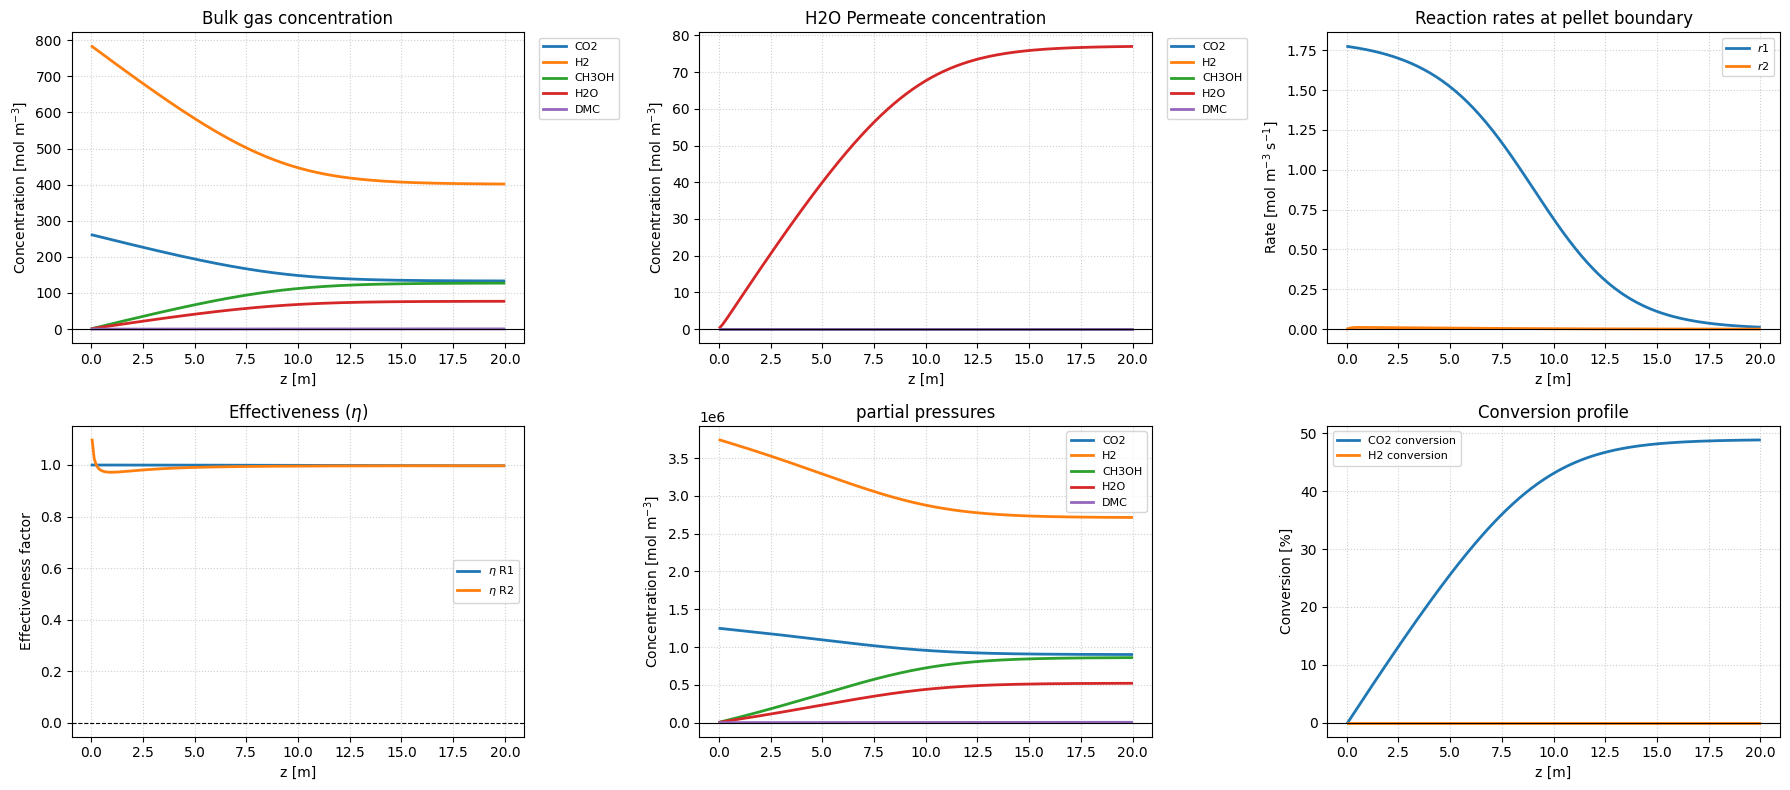

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False)
axes = axes.flatten()
 
# axes[0]: Bulk Gas Concentration
for i, label in enumerate(model.species_labels):
    axes[0].plot(model.z_c, c_g[:, i], label=label, linewidth=2)
axes[0].axhline(0.0, color="k", linewidth=0.8)
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("Concentration [mol m$^{-3}$]")
axes[0].set_title("Bulk gas concentration")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), ncol=1, fontsize=8, frameon=True)
axes[0].grid(True, linestyle=":", alpha=0.6)
 
# axes[1]: H2O Permeate Concentration
for i, label in enumerate(model.species_labels):
    axes[1].plot(model.z_c, c_m[:, i], label=label, linewidth=2)
axes[1].axhline(0.0, color="k", linewidth=0.8)
axes[1].set_xlabel("z [m]")
axes[1].set_ylabel(r"Concentration [mol m$^{-3}$]")
axes[1].set_title("H2O Permeate concentration")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), ncol=1, fontsize=8, frameon=True)
axes[1].grid(True, linestyle=":", alpha=0.6)
 
# axes[2]: Reaction Rates
axes[2].plot(model.z_c, r1, label=r"$r1$", linewidth=2)
axes[2].plot(model.z_c, r2, label=r"$r2$", linewidth=2)
axes[2].axhline(0.0, color="k", lw=0.8)
axes[2].set_xlabel("z [m]")
axes[2].set_ylabel("Rate [mol m$^{-3}$ s$^{-1}$]")
axes[2].set_title("Reaction rates at pellet boundary")
axes[2].legend(loc="best", fontsize=8)
axes[2].grid(True, linestyle=":", alpha=0.6)
 
# axes[3]: Effectiveness Profile
axes[3].plot(model.z_c, eta_r1, label=r"$\eta$ R1", linewidth=2)
axes[3].plot(model.z_c, eta_r2, label=r"$\eta$ R2", linewidth=2)
axes[3].axhline(0.0, color="k", linewidth=0.8, linestyle="--")
axes[3].set_xlabel("z [m]")
axes[3].set_ylabel("Effectiveness factor")
axes[3].set_title(r"Effectiveness ($\eta$)")
axes[3].grid(True, linestyle=":", alpha=0.6)
axes[3].legend(loc="best", fontsize=8)

for i, label in enumerate(model.species_labels):
    axes[4].plot(model.z_c, P_pa_bulk[:, i], label=label, linewidth=2)
axes[4].axhline(0.0, color="k", linewidth=0.8)
axes[4].set_ylabel("Concentration [mol m$^{-3}$]")
axes[4].set_title("partial pressures")
axes[4].legend(fontsize=8)
axes[4].grid(True, linestyle=":", alpha=0.6)

axes[5].plot(model.z_c, X_CO2 * 100, label="CO2 conversion", linewidth=2)
axes[5].plot(model.z_c, X_MeOH * 100, label="H2 conversion", linewidth=2)
axes[5].axhline(0.0, color="k", linewidth=0.8)
axes[5].set_xlabel("z [m]")
axes[5].set_ylabel("Conversion [%]")
axes[5].set_title("Conversion profile")
axes[5].legend(fontsize=8)
axes[5].grid(True, linestyle=":", alpha=0.6)
 
plt.tight_layout()
plt.show()